# MBDoE 2026 Lot 2: integrated data preview and QC

## tl;dr

This notebook reconstructs the three synthetic-must Lot 2 fermentations from raw laboratory and process files. It preserves raw analytical values, creates separately named model-safe values, and makes every timing or identifier repair auditable. The executed outputs below determine which observations can enter the next calibration and estimability comparison.

## Context & Methods

### Key assumptions

1. The first Oculyze sample defines $t=0$ for each reactor.
2. Oculyze concentration is total cells in million cells/mL. Using 30 pg/cell,

$$X_{\mathrm{total}}[\mathrm{g/L}] = C[10^6\,\mathrm{cells/mL}]\times 0.03.$$

Viable and dead biomass are

$$X = X_{\mathrm{total}}\frac{V}{100},\qquad X_d=X_{\mathrm{total}}-X.$$

3. Ethanol is recomputed from manual entries using $E[\mathrm{g/L}]=7.89\,E[\%\,v/v]$.
4. A measured-ethanol sample removes 50 mL; another sample with analytical evidence removes 5 mL. A planned row without any measurement evidence removes 0 mL.
5. CO2 flow is normalized to the initial 2 L volume with

$$q_{\mathrm{CO_2},0}=q_{\mathrm{CO_2}}\frac{V_0}{V(t)}.$$

Protocol events and inferred times are labeled; they are not presented as direct observations.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
while ROOT.name != "pyomo-doe" and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if ROOT.name != "pyomo-doe":
    raise RuntimeError("Run this notebook from inside the pyomo-doe repository")

import sys
FERMENTATION_MODEL = ROOT / "fermentation_model"
if str(FERMENTATION_MODEL) not in sys.path:
    sys.path.insert(0, str(FERMENTATION_MODEL))

from laboratory_2026 import run_lot2_data_preview as analysis

summary = analysis.run_pipeline()
summary

{'n_processes': 3,
 'n_sample_rows': 54,
 'n_samples_with_observation_evidence': 52,
 'n_y15_samples': 44,
 'n_ethanol_measured': 37,
 'n_ethanol_used_after_qc': 36,
 'n_biomass_observations': 49,
 'n_oculyze_id_or_time_repairs': 4,
 'n_oculyze_duplicate_context_rows': 6,
 'n_y15_conflicts': 0,
 'time_zero_definition': 'first Oculyze sample per process',
 'biomass_conversion_g_per_cell': 3e-11,
 'ethanol_conversion_g_l_per_percent_vv': 7.89}

## Data

In [2]:
processed = analysis.PROCESSED_DIR
qc = pd.read_csv(processed / "lot2_data_qc_summary.csv")
samples = pd.read_csv(processed / "lot2_samples_integrated.csv")
inputs = pd.read_csv(processed / "lot2_operational_inputs.csv")
repairs = pd.read_csv(processed / "lot2_oculyze_repairs.csv")
display(qc)
display(inputs)
display(repairs)

,process,n_sample_rows,n_samples_with_observation_evidence,n_y15_samples,n_ethanol,n_ethanol_used_after_qc,n_biomass,n_time_inferred,n_negative_censored,final_sampling_only_volume_ml,temperature_first_h,temperature_last_h,co2_first_h,co2_last_h,chemistry_last_h
0,F1,18,18,15,13,13,17,2,4,1325.0,0.666667,99.833333,0.666667,99.833333,190.0
1,F2,18,18,15,13,12,17,2,4,1325.0,0.666667,99.833333,0.833333,99.833333,190.0
2,F3,18,16,14,11,11,15,1,5,1425.0,0.833333,99.833333,0.833333,99.833333,168.0


,process,candidate,channel,amount,volume_ml,nominal_relative_time_h,actual_or_model_time_h,datetime_reanchored,evidence,details
0,F1,synthetic_glucose_rich_fructose_pulse,N,0.05,4.58500,26.0,26.000000,2026-07-07 14:00:00.000000000,protocol_nominal_unverified,manual N addition from stock
1,F1,synthetic_glucose_rich_fructose_pulse,F,35.00,81.12925,74.0,71.833333,2026-07-09 11:49:59.999999998,controller_flag_plus_observed_fructose_jump,manual F addition from stock
2,F3,synthetic_viable_biomass_step,N,0.05,4.58500,26.0,26.000000,2026-07-07 14:00:00.000000000,protocol_nominal_unverified,manual N addition from stock
3,F3,synthetic_viable_biomass_step,X,1.00,17.22585,50.0,50.000000,2026-07-08 14:00:00.000000000,protocol_time_plus_observed_biomass_step,manual X addition from stock


,process,sample_id_raw,sample_id,raw_datetime,used_datetime,repair_reason,record_changed
0,F1,DOE-LAB004-16,DOE-LAB004-16,2026-07-13 12:00:00,2026-07-13 12:00:00,duplicate_time_context,False
1,F1,DOE-LAB004-17,DOE-LAB004-17,2026-07-13 12:00:00,2026-07-13 16:30:00,duplicate_description_time_repaired,True
2,F2,DOE-LAB005-1,DOE-LAB005-9,2026-07-08 14:30:00,2026-07-08 14:30:00,sequence_id_repair,True
3,F2,DOE-LAB005-16,DOE-LAB005-16,2026-07-13 12:00:00,2026-07-13 12:00:00,duplicate_time_context,False
4,F2,DOE-LAB005-17,DOE-LAB005-17,2026-07-13 12:00:00,2026-07-13 16:30:00,duplicate_description_time_repaired,True
5,F3,DOE-LAB006-5,DOE-LAB006-15,2026-07-10 12:30:00,2026-07-10 12:30:00,sequence_id_repair,True


### Data-quality rules

- Raw negative analytical values remain available. Only columns ending in `for_model` are censored at zero.
- Oculyze identifiers are repaired only when the row sequence makes the typo unambiguous; the raw identifier remains beside the repaired one.
- Missing collection times are estimated from Y15 analysis time minus the process-specific median analytical lag.
- The ethanol mass-balance flag is a screening test, not an automatic data correction.

In [3]:
columns = [
    "process", "sample_id", "sample_sequence", "sample_datetime_used", "t_h",
    "sample_time_source", "glucose_g_l", "fructose_g_l_raw", "yan_for_model_physical_mg_l",
    "ethanol_g_l_for_model", "ethanol_use_for_model", "glycerol_g_l", "x_viable_g_l",
    "x_dead_g_l", "reactor_volume_after_sample_ml"
]
display(samples[columns].head(24))

,process,sample_id,sample_sequence,sample_datetime_used,t_h,sample_time_source,glucose_g_l,fructose_g_l_raw,yan_for_model_physical_mg_l,ethanol_g_l_for_model,ethanol_use_for_model,glycerol_g_l,x_viable_g_l,x_dead_g_l,reactor_volume_after_sample_ml
0,F1,DOE-LAB004-1,1,2026-07-06 12:00:00.000000000,0.000000,oculyze_description,120.36,50.41,200.0,2.3670,True,0.31,0.074889,0.033411,1950.0
1,F1,DOE-LAB004-2,2,2026-07-06 15:10:29.000000000,3.174722,y15_analysis_start_minus_process_median_lag,117.48,47.36,187.0,NaN,False,0.31,NaN,NaN,1945.0
2,F1,DOE-LAB004-3,3,2026-07-06 16:30:00.000000000,4.500000,oculyze_description,116.81,47.47,187.0,2.5248,True,0.39,0.182130,0.029970,1895.0
3,F1,DOE-LAB004-4,4,2026-07-07 09:00:00.000000000,21.000000,oculyze_description,110.38,42.56,133.0,5.5230,True,1.13,0.279919,0.021880,1845.0
4,F1,DOE-LAB004-5,5,2026-07-07 12:00:00.000000000,24.000000,oculyze_description,106.38,44.17,154.0,NaN,False,0.91,0.354867,0.020733,1840.0
5,F1,DOE-LAB004-6,6,2026-07-07 15:00:00.000000000,27.000000,oculyze_description,101.75,43.78,146.0,NaN,False,1.08,0.428526,0.024174,1835.0
6,F1,DOE-LAB004-7,7,2026-07-07 17:00:00.000000000,29.000000,oculyze_description,NaN,NaN,NaN,8.5212,True,NaN,0.320275,0.018425,1785.0
7,F1,DOE-LAB004-8,8,2026-07-08 09:00:00.000000000,45.000000,oculyze_description,83.87,37.43,30.0,20.0406,True,2.99,1.246430,0.041470,1735.0
8,F1,DOE-LAB004-9,9,2026-07-08 14:30:00.000000000,50.500000,oculyze_description,74.31,38.51,24.0,NaN,False,2.98,1.433234,0.039166,1730.0
9,F1,DOE-LAB004-10,10,2026-07-08 16:00:00.000000000,52.000000,oculyze_description,73.66,37.73,27.0,21.1452,True,2.51,1.384841,0.059959,1680.0


## Results

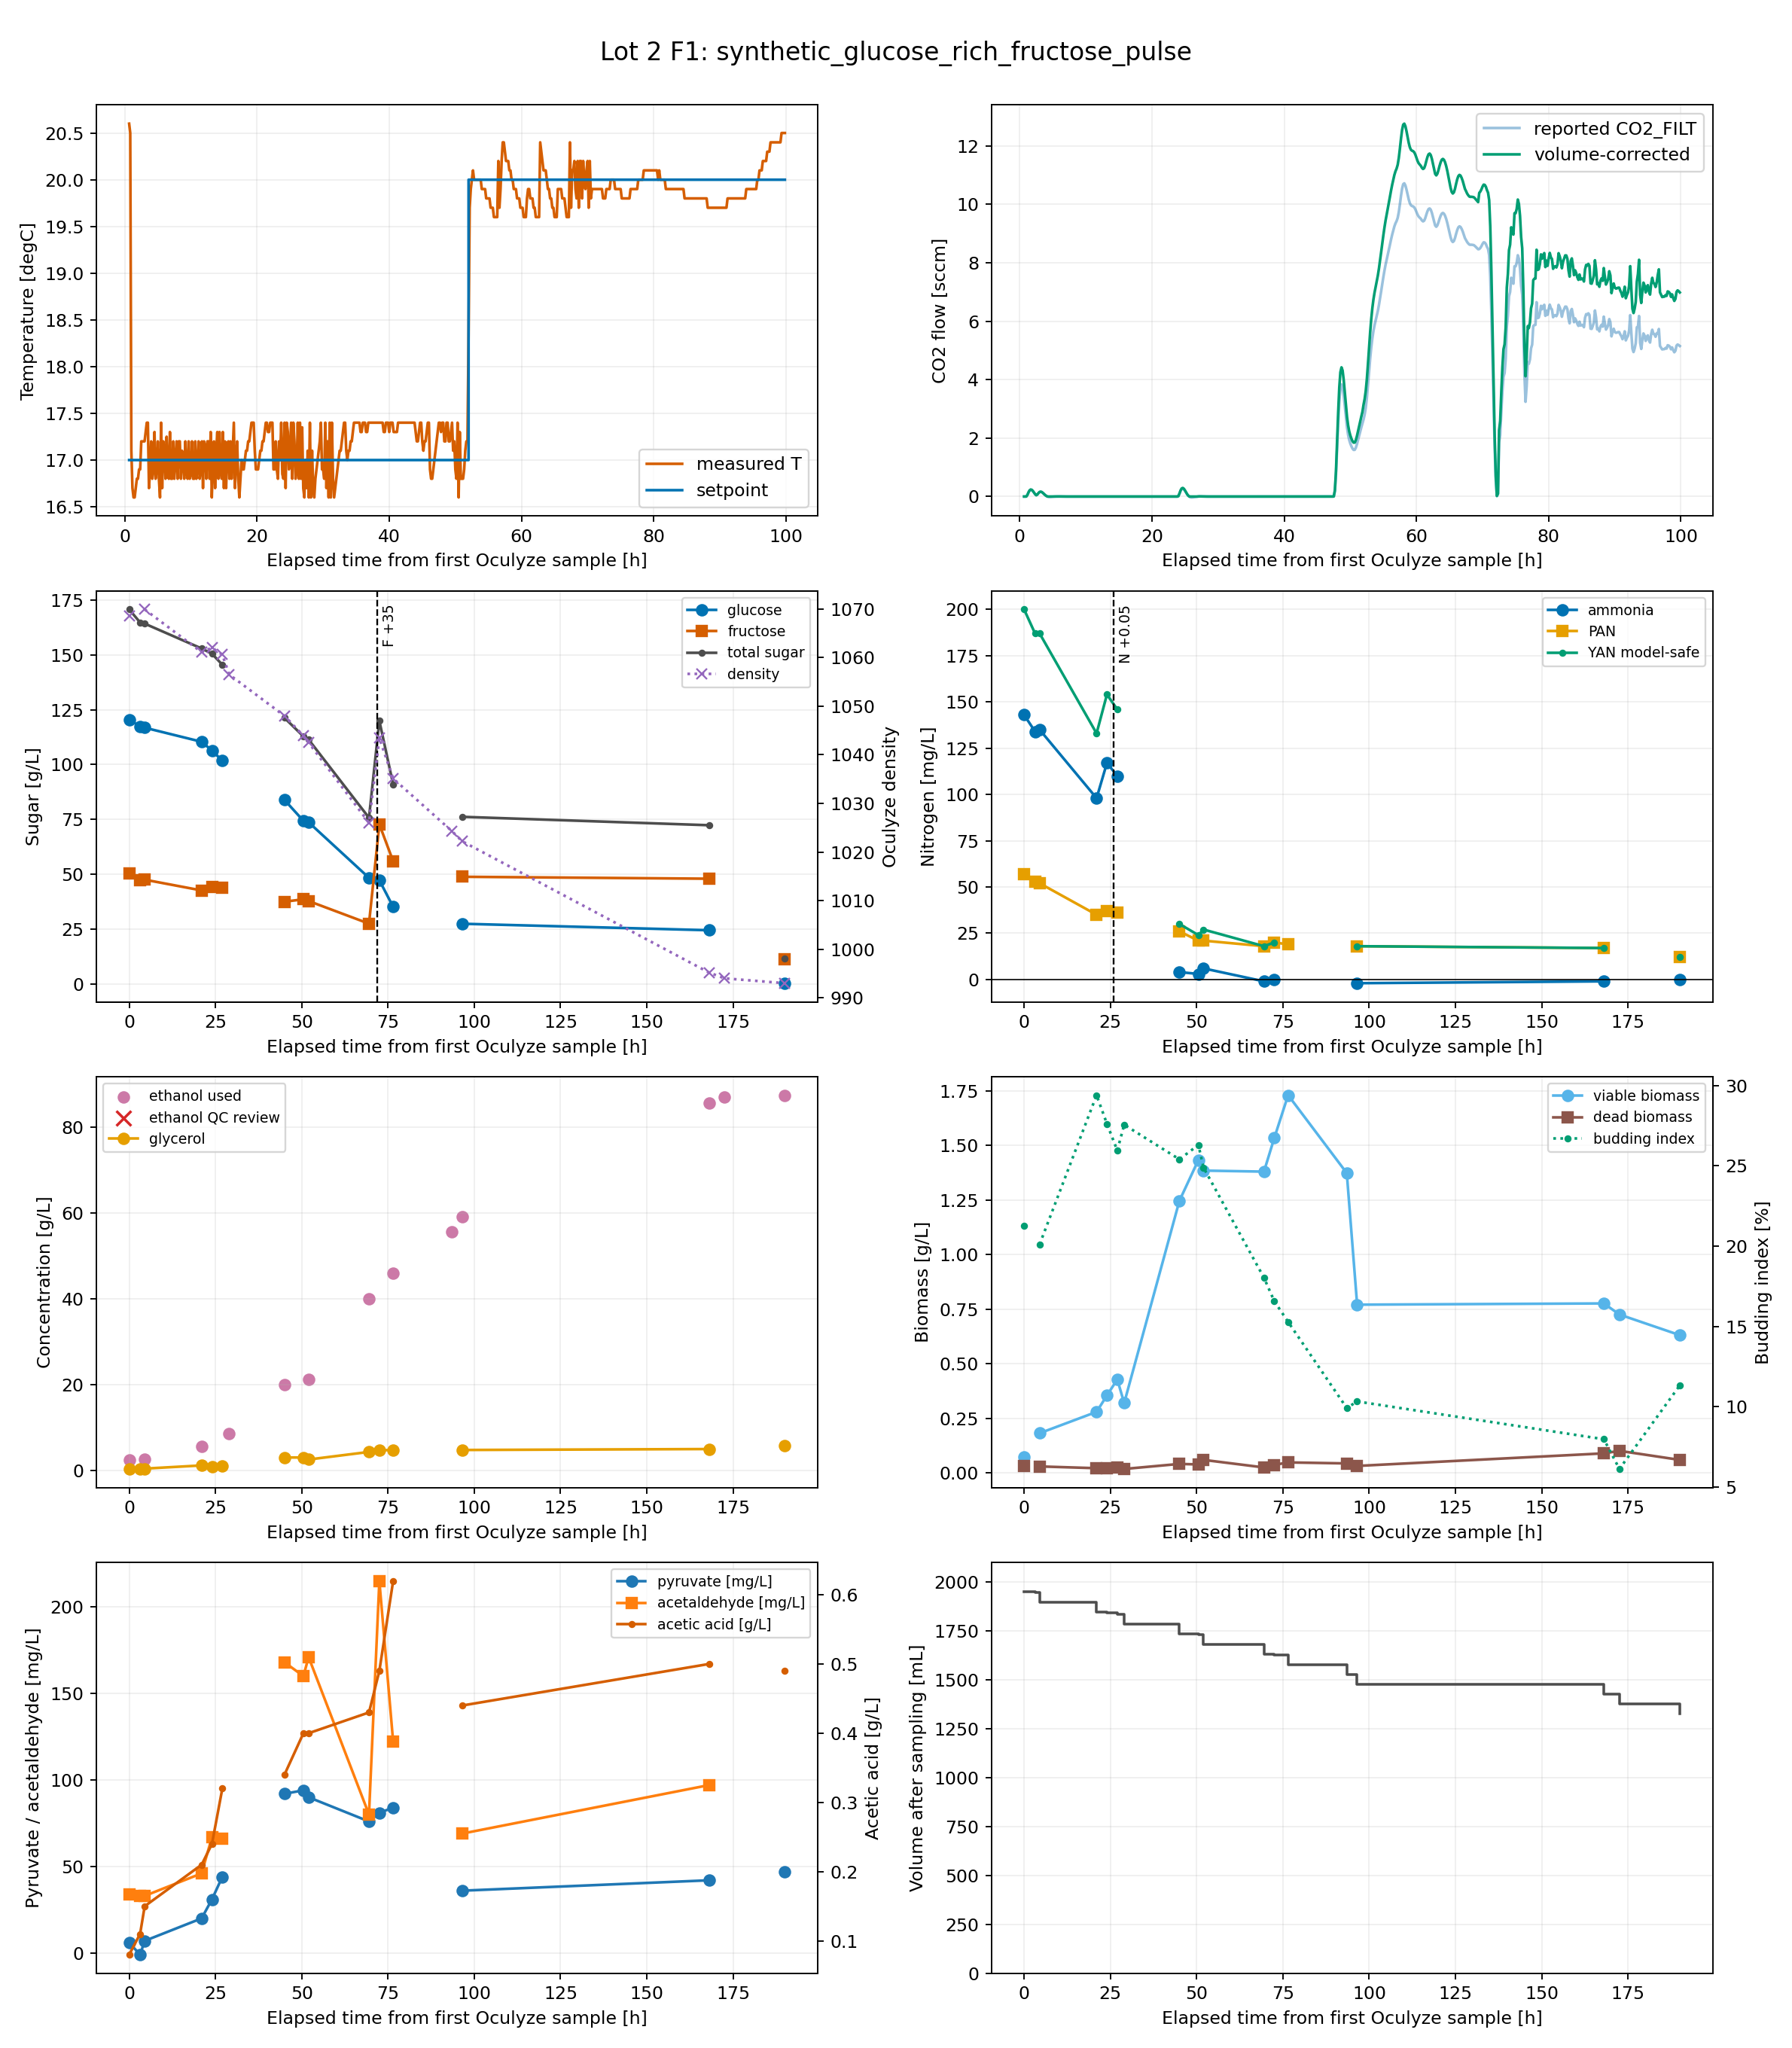

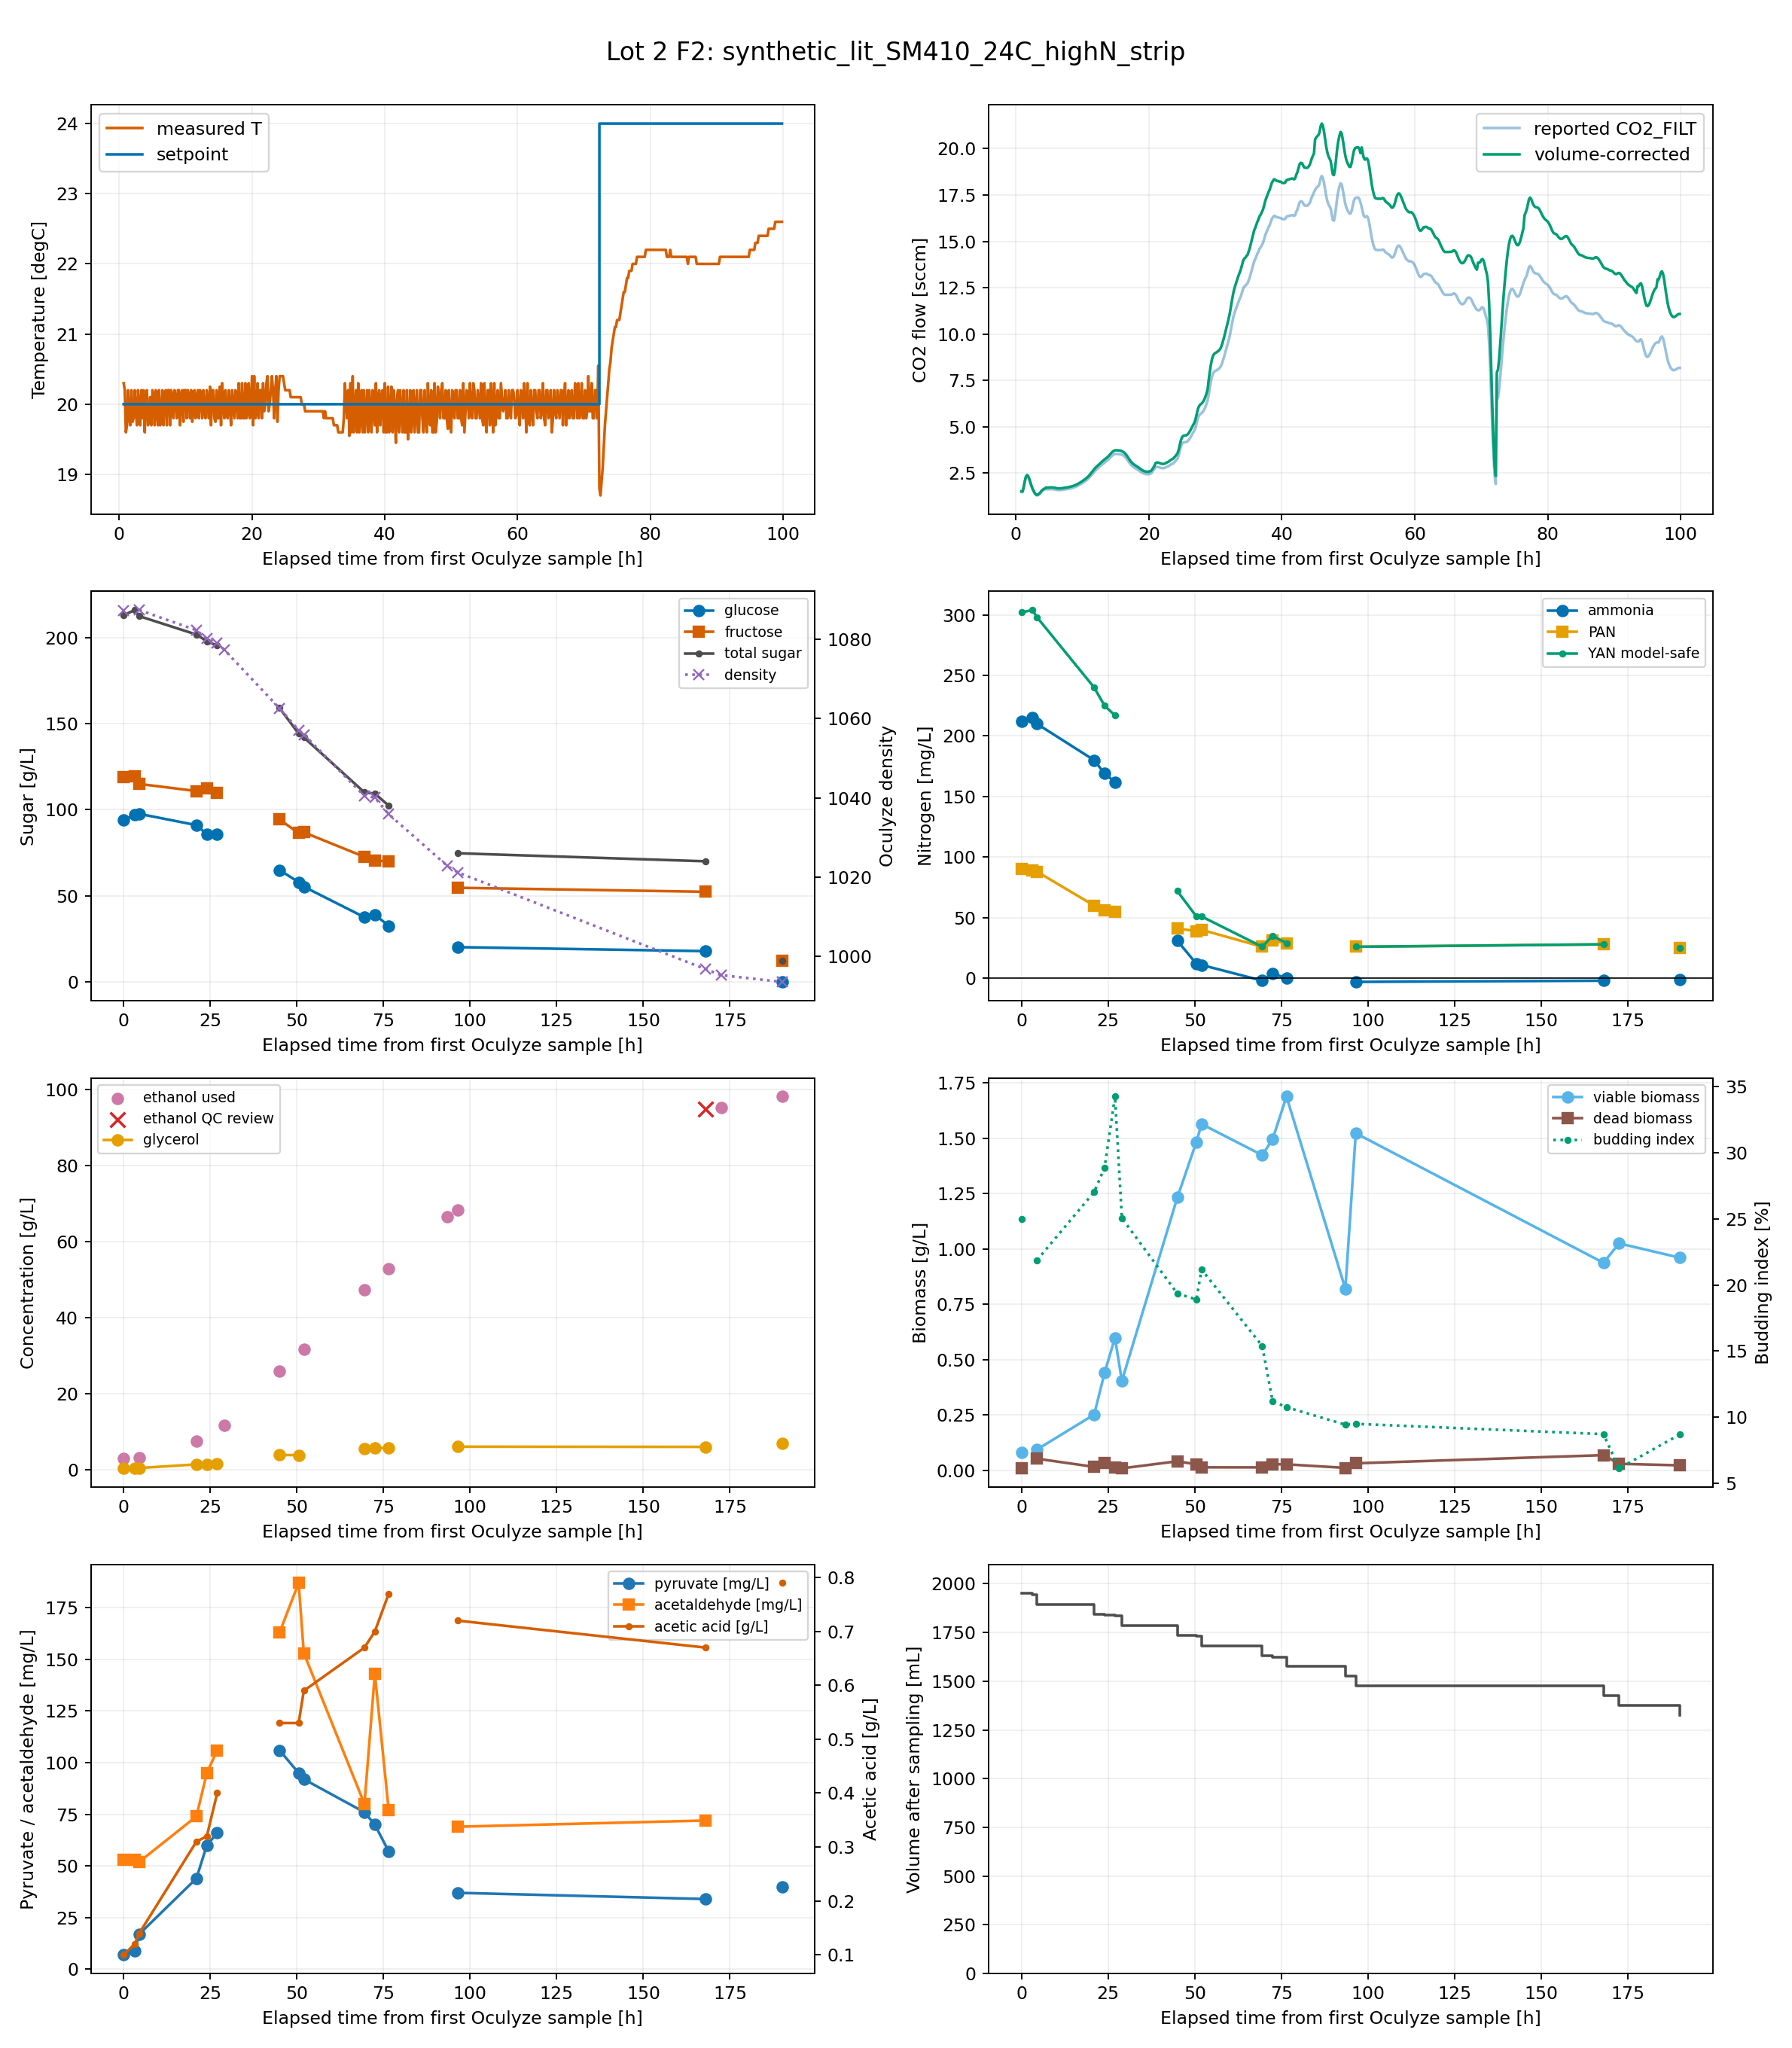

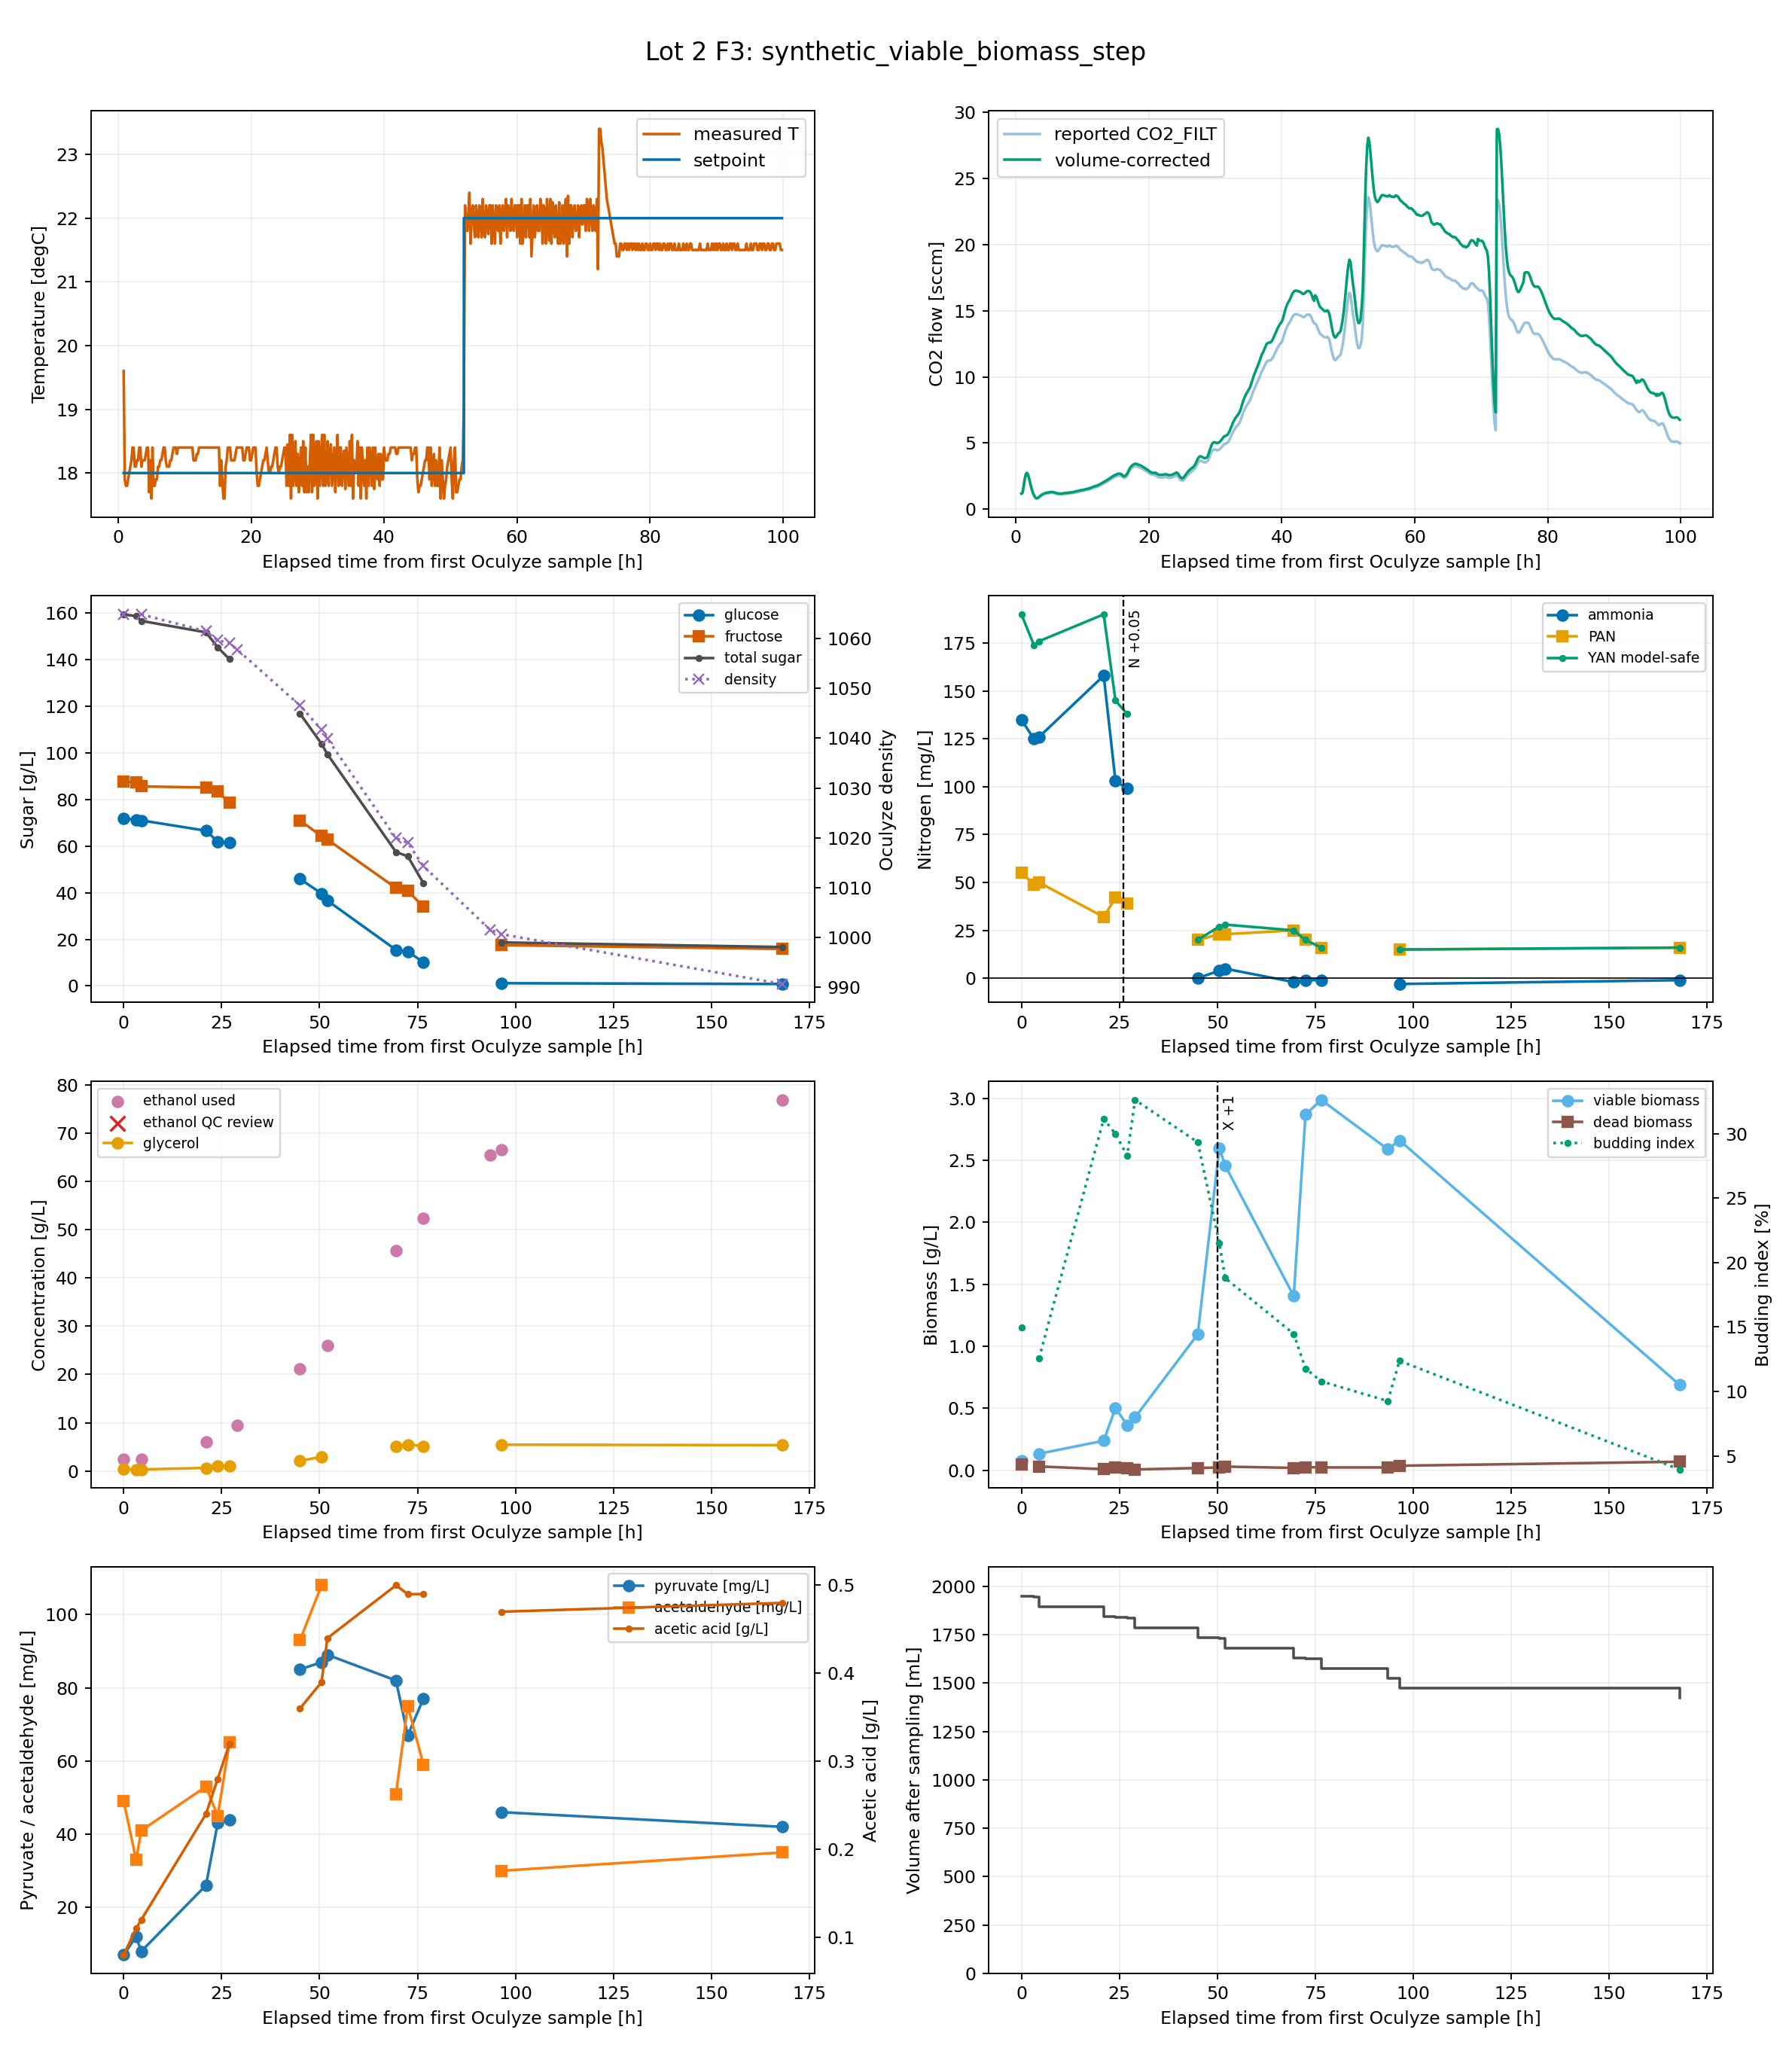

In [4]:
for process in ("F1", "F2", "F3"):
    display(Image(filename=str(analysis.FIGURE_DIR / f"lot2_{process}_process_preview.png")))

## Takeaways

In [5]:
display(Markdown((analysis.RESULTS_DIR / "lot2_data_quality_report.md").read_text(encoding="utf-8")))

# Lot 2 data ingestion and QC

## Scope

This artifact integrates Y15 chemistry, manual ethanol entries, Oculyze biomass, online temperature, and online CO2 for the three synthetic-must MBDoE fermentations in Lot 2.

## Main conventions

- Time zero is the first Oculyze sample in each reactor.
- Total Oculyze concentration is interpreted as million cells/mL. Biomass uses 30 pg/cell.
- Negative low-range analytical readings are preserved in raw columns and censored at zero only in explicitly named model-safe columns.
- Ethanol is recomputed from the entered replicates as `% v/v * 7.89 = g/L`; cached Excel formula cells are ignored.
- Sampling removes 50 mL when ethanol was measured and 5 mL for another sample with analytical evidence. Planned rows without any measurement evidence remove 0 mL. The CO2 flow is normalized back to the initial 2 L volume.
- Planned input events are not silently treated as executed. The F1 fructose pulse and F3 biomass step have trajectory evidence; nitrogen pulse times remain protocol-based and unverified.

## QC summary

| process   |   n_sample_rows |   n_samples_with_observation_evidence |   n_y15_samples |   n_ethanol |   n_ethanol_used_after_qc |   n_biomass |   n_time_inferred |   n_negative_censored |   final_sampling_only_volume_ml |   temperature_first_h |   temperature_last_h |   co2_first_h |   co2_last_h |   chemistry_last_h |
|:----------|----------------:|--------------------------------------:|----------------:|------------:|--------------------------:|------------:|------------------:|----------------------:|--------------------------------:|----------------------:|---------------------:|--------------:|-------------:|-------------------:|
| F1        |              18 |                                    18 |              15 |          13 |                        13 |          17 |                 2 |                     4 |                            1325 |              0.666667 |              99.8333 |      0.666667 |      99.8333 |                190 |
| F2        |              18 |                                    18 |              15 |          13 |                        12 |          17 |                 2 |                     4 |                            1325 |              0.666667 |              99.8333 |      0.833333 |      99.8333 |                190 |
| F3        |              18 |                                    16 |              14 |          11 |                        11 |          15 |                 1 |                     5 |                            1425 |              0.833333 |              99.8333 |      0.833333 |      99.8333 |                168 |

## Repaired Oculyze records

| process   | sample_id_raw   | sample_id     | raw_datetime        | used_datetime       | repair_reason                       | record_changed   |
|:----------|:----------------|:--------------|:--------------------|:--------------------|:------------------------------------|:-----------------|
| F1        | DOE-LAB004-16   | DOE-LAB004-16 | 2026-07-13 12:00:00 | 2026-07-13 12:00:00 | duplicate_time_context              | False            |
| F1        | DOE-LAB004-17   | DOE-LAB004-17 | 2026-07-13 12:00:00 | 2026-07-13 16:30:00 | duplicate_description_time_repaired | True             |
| F2        | DOE-LAB005-1    | DOE-LAB005-9  | 2026-07-08 14:30:00 | 2026-07-08 14:30:00 | sequence_id_repair                  | True             |
| F2        | DOE-LAB005-16   | DOE-LAB005-16 | 2026-07-13 12:00:00 | 2026-07-13 12:00:00 | duplicate_time_context              | False            |
| F2        | DOE-LAB005-17   | DOE-LAB005-17 | 2026-07-13 12:00:00 | 2026-07-13 16:30:00 | duplicate_description_time_repaired | True             |
| F3        | DOE-LAB006-5    | DOE-LAB006-15 | 2026-07-10 12:30:00 | 2026-07-10 12:30:00 | sequence_id_repair                  | True             |

## Ethanol points held for review

The following points fail a deliberately conservative sugar-to-ethanol screening rule. They remain visible in plots and processed data but are excluded from the default calibration table until sample timing or measurement identity is confirmed.

| process   | sample_id     |   t_h |   sugar_total_g_l |   ethanol_g_l_for_model | ethanol_mass_balance_screen        |
|:----------|:--------------|------:|------------------:|------------------------:|:-----------------------------------|
| F2        | DOE-LAB005-16 |   168 |             70.01 |                 94.8378 | review_time_mapping_or_measurement |

## Interpretation boundary

The online process files end near 99 h, whereas chemistry continues to approximately 190 h. Cumulative CO2 after the last online record is therefore a lower bound, not a full-batch mass balance.
